In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [19]:
df= pd.read_csv("insurance.csv")
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [20]:
types=df.dtypes
unique=df.nunique()
pd.DataFrame({"type": types, "unique": unique}).T

,age,sex,bmi,children,smoker,region,charges
type,int64,str,float64,int64,str,str,float64
unique,47,2,548,6,2,4,1337


In [21]:
cols = ['sex','bmi','smoker','region','charges']
df[cols] = df[cols].astype('category')

In [22]:
pd.DataFrame({"type": df.dtypes, "unique": df.nunique()}).T

,age,sex,bmi,children,smoker,region,charges
type,int64,category,category,int64,category,category,category
unique,47,2,548,6,2,4,1337


In [23]:
df.shape[0]

1338

In [24]:
null=df.isnull().sum()
ratio=null/df.shape[0]
pd.DataFrame({"null": null, "ratio": ratio}).T

,age,sex,bmi,children,smoker,region,charges
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0


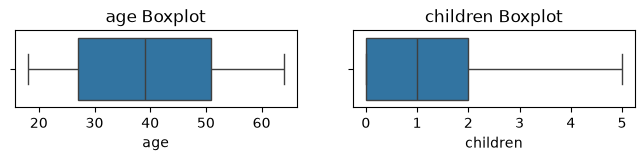

In [25]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [26]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

C:\Users\MOBI LAP\AppData\Local\Temp\ipykernel_4164\195205220.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
C:\Users\MOBI LAP\AppData\Local\Temp\ipykernel_4164\195205220.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through cha

In [27]:
df.duplicated().sum()

np.int64(1)

In [28]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [29]:
df.drop_duplicates(inplace=True)

In [31]:
df.duplicated().sum()

np.int64(0)

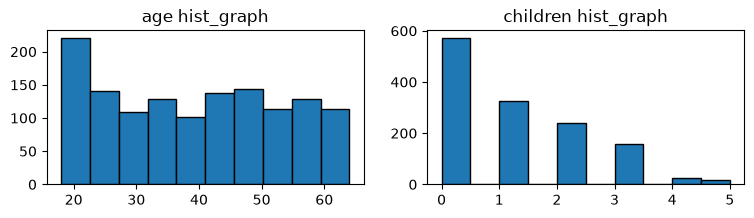

In [32]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


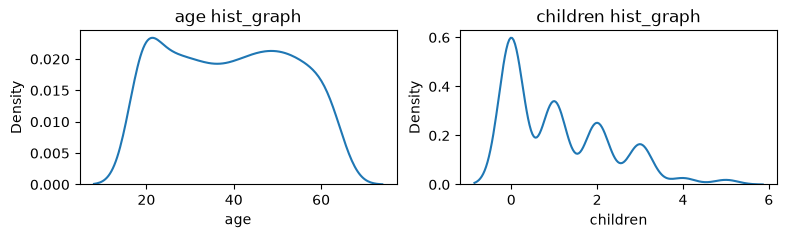

In [33]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [34]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['sex', 'bmi', 'smoker', 'region', 'charges'], dtype='str')

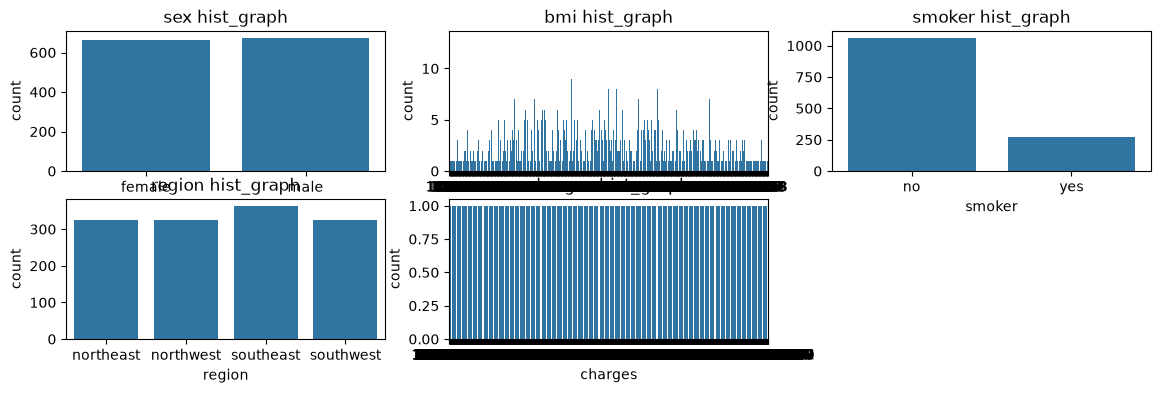

In [35]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.show()

In [37]:
unique = df['region'].value_counts()
count = unique.values
print(unique)
print(count)

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64
[364 325 324 324]


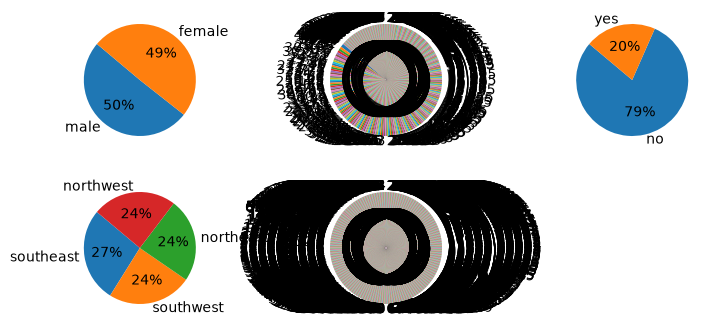

In [38]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

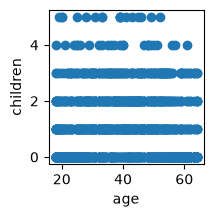

In [43]:
plt.figure(figsize=(2,2))
plt.scatter(df['age'], df['children'])
plt.xlabel("age")
plt.ylabel("children")
plt.show()

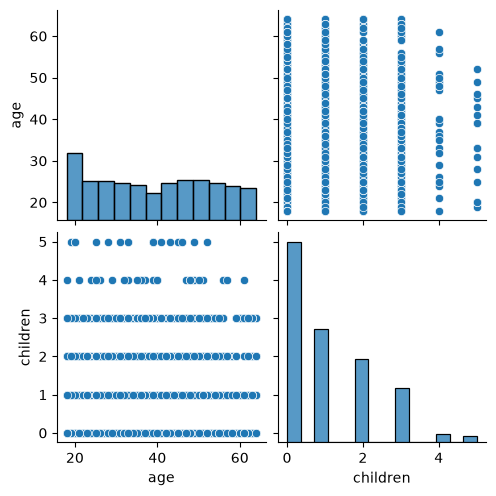

In [44]:
sns.pairplot(df)

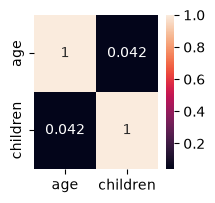

In [45]:
corr  =  df[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()